# Laboratorio Semana 4: Seq2Seq Ingles-Espanol desde cero

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

Esta semana implementa un modelo Seq2Seq completo para traduccion ingles-espanol con traducciones **naturales en espanol**: el corpus tiene deliberadamente oraciones donde el espanol es mas corto (por elision del sujeto: *she sings well* -> *canta bien*), mas largo (por perifrasis verbales: *the cat sleeps* -> *el gato esta durmiendo*), o del mismo largo. Esa asimetria de largo es exactamente la razon de ser de la arquitectura Encoder-Decoder.

Pipeline:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> c = h_T^enc
                                            |
<SOS>+oracion_ES -> [E_dec] -> [Decoder LSTM] -> [W_out+softmax] -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.LSTM`, `nn.Embedding`, `nn.Linear` ni capas de alto nivel.
- El backward debe ser **manual**. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [162]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
from collections import Counter
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cu130


---
## Bloque 0: Corpus, vocabularios y pesos iniciales (dado, no modificar)

In [163]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

# Split 75/25 reproducible
random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Primer par de entrenamiento: {TRAIN_DATA[0]}')
# Verificar distribucion de largos
diffs = [len(tgt.split())-len(src.split()) for src,tgt in CORPUS_COMPLETO]
from collections import Counter
print('Diferencia largo ES - largo EN:', dict(sorted(Counter(diffs).items())))


Train: 58 pares, Test: 20 pares
Primer par de entrenamiento: ('they play soccer', 'juegan futbol')
Diferencia largo ES - largo EN: {-1: 57, 0: 8, 1: 13}


In [164]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V} palabras')
print(f'Vocabulario ES: {tgt_V} palabras')

def tokenize_src(sentence):
    return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in sentence.split()]

def tokenize_tgt(sentence):
    return ([tgt_w2i[SOS]] +
            [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in sentence.split()] +
            [tgt_w2i[EOS]])

Vocabulario EN: 158 palabras
Vocabulario ES: 163 palabras


In [165]:
d_emb = 16; d_hid = 32
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
W_out = torch.randn(tgt_V, d_hid) * 0.1; b_out = torch.zeros(tgt_V)
alpha = 0.01
print(f'E_enc: {E_enc.shape}, Wf_enc: {Wf_enc.shape}, W_out: {W_out.shape}')

E_enc: torch.Size([16, 158]), Wf_enc: torch.Size([32, 48]), W_out: torch.Size([163, 32])


---
## Bloque 1: Lookup de embeddings

Implemente `get_embedding` que selecciona la columna `idx` de la matriz `E`:

$$\mathbf{e} = E[:, \text{idx}]$$

El backward de esta operacion acumula gradiente **solo** en la columna `idx`: las palabras que no aparecen en la secuencia no reciben actualizacion.

Implemente tambien `get_embedding_batch` para una lista de indices.

In [166]:
def get_embedding(E, idx):
    """
    Selecciona la columna idx de E. Retorna tensor (d_emb,).
    """
    return E[:, idx]


def get_embedding_batch(E, indices):
    """Retorna lista de embeddings para una lista de indices."""
    return [get_embedding(E, idx) for idx in indices]

emb_test = get_embedding(E_enc, 0)
print(f'Embedding token 0: {emb_test.shape if emb_test is not None else None}')

Embedding token 0: torch.Size([16])


---
## Bloque 2: Celda LSTM y forward del encoder

Implemente `lstm_cell` con las cinco ecuaciones del LSTM.  
Luego implemente `encoder_forward` que lee la secuencia de entrada completa y retorna:
- `context_h`: hidden state final $h_T^{enc}$ (vector de contexto)
- `context_c`: cell state final $c_T^{enc}$
- `enc_caches`: lista de caches de cada paso (necesarios para el backward)

Guarde el indice del embedding en cada cache con la clave `'emb_idx'`.

**Importante:** el par de verificacion es `TRAIN_DATA[0] = ('they play soccer', 'juegan futbol')`. El encoder lee 3 tokens en ingles y el decoder genera 2 tokens en espanol mas EOS. Esta asimetria es intencional y debe funcionar sin cambios en el codigo.

In [167]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    """
    Un paso de tiempo LSTM.
    Retorna (h_new, c_new, cache).
    El cache debe contener: concat, h_prev, c_prev, f, i, ct, c_t, o, h_t
    """

    # Concatenar [h_t, x_t]
    concat = torch.cat([h, x])

    # Forget Gate
    f = torch.sigmoid(Wf @ concat + bf)

    # Input gate
    i = torch.sigmoid(Wi @ concat + bi)

    # Candidate
    ct = torch.tanh(Wc @ concat + bc)

    # Cell state
    c_t = f * c + i * ct

    # Output gate
    o = torch.sigmoid(Wo @ concat + bo)

    # Hidden state
    h_t = o * torch.tanh(c_t)

    # Cache
    cache = {
        'concat': concat,
        'h_prev': h,
        'c_prev': c,
        'f': f,
        'i': i,
        'ct': ct,
        'c_t': c_t,
        'o': o,
        'h_t': h_t,
    }

    return h_t, c_t, cache


def encoder_forward(src_indices, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc,
                    Wc_enc, bc_enc, Wo_enc, bo_enc):
    """
    Forward del encoder. Retorna (context_h, context_c, enc_caches).
    """

    # Inicializar h, c en ceros (no hay estado previo)
    h = torch.zeros(d_hid)
    c = torch.zeros(d_hid)

    # Inicializar lista vacía de caches en cada paso
    enc_caches = []

    # Para cada idx
    for idx in src_indices:
        # Obtener el embedding
        emb = get_embedding(E_enc, idx)

        # Celda de LSTM, actualizar h, c y cache.
        h, c, cache = lstm_cell(h, c, emb, Wf_enc, bf_enc, Wi_enc, bi_enc,
                                Wc_enc, bc_enc, Wo_enc, bo_enc)
        
        # Guardar índice del embedding
        cache['emb_idx'] = idx

        # Agregar cache a la lista
        enc_caches.append(cache)

    # Al terminar el loop h y c son h_T y c_T, el vector de contexto
    context_h = h
    context_c = c

    return context_h, context_c, enc_caches

# Verificar con TRAIN_DATA[0]: 'they play soccer' -> 'juegan futbol'
src_test = tokenize_src(TRAIN_DATA[0][0])
context_h, context_c, enc_caches = encoder_forward(
    src_test, E_enc, Wf_enc, bf_enc, Wi_enc, bi_enc, Wc_enc, bc_enc, Wo_enc, bo_enc)
print(f'Entrada EN: {TRAIN_DATA[0][0]} -> tokens: {src_test}')
print(f'context_h forma: {context_h.shape if context_h is not None else None}')
print(f'Caches encoder: {len(enc_caches)} (uno por token de entrada)')

Entrada EN: they play soccer -> tokens: [138, 103, 122]
context_h forma: torch.Size([32])
Caches encoder: 3 (uno por token de entrada)


In [168]:
# VERIFICACION BLOQUE 2
_H = 'a1c22d089ecfb52bdae47e330603a46d492f9318dc6b2071956ef1a9c406eeec'
try:
    assert context_h is not None and context_h.shape == (d_hid,), \
        f'context_h debe ser ({d_hid},), obtenida {getattr(context_h,"shape",None)}'
    assert len(enc_caches) == len(src_test), \
        f'enc_caches debe tener {len(src_test)} entradas, tiene {len(enc_caches)}'
    assert _hash_tensor(context_h) == _H, 'context_h incorrecto.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Forward del decoder con teacher forcing

Implemente `decoder_forward` con teacher forcing.

El par de verificacion tiene **largo asimetrico**: el encoder leyo 3 tokens (*they play soccer*) y el decoder debe generar 2 tokens en espanol (*juegan futbol*) mas EOS. Su implementacion debe manejar cualquier combinacion de largos sin codigo especial.

- Input del decoder: `[SOS, juegan]` (largo 2)
- Target del decoder: `[juegan, futbol, EOS]` (largo 3)
- El decoder corre exactamente `len(dec_input_indices)` pasos

In [169]:
def decoder_forward(dec_input_indices, dec_target_indices, context_h, context_c,
                    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec,
                    Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out):
    """
    Forward decoder con teacher forcing.
    Retorna (logits_list, dec_caches)
    logits_list: lista de tensores (tgt_V,), uno por paso
    """

    # Inicializar h, c
    h = context_h.clone()
    c = context_c.clone()

    # Lista de caches
    dec_caches = []

    # Logits
    logits_list = []

    # Para cada idx
    for idx in dec_input_indices:
        # Obtener el embedding
        emb = get_embedding(E_dec, idx)

        # Celda de LSTM, actualizar h, c y cache.
        h, c, cache = lstm_cell(h, c, emb, Wf_dec, bf_dec, Wi_dec, bi_dec,
                                Wc_dec, bc_dec, Wo_dec, bo_dec)

        # Guardar índice del embedding
        cache['emb_idx'] = idx

        # Agregar cache a la lista
        dec_caches.append(cache)

        # Calcular y guardar logits
        z = W_out @ h + b_out
        logits_list.append(z)
        
    return logits_list, dec_caches

tgt_tokens_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_tokens_full[:-1]   # [SOS, juegan]
dec_target_idx = tgt_tokens_full[1:]    # [juegan, futbol, EOS]
print(f'Salida ES: {TRAIN_DATA[0][1]} -> tokens: {tgt_tokens_full}')
print(f'Input decoder:  {dec_input_idx}  (largo {len(dec_input_idx)})')
print(f'Target decoder: {dec_target_idx} (largo {len(dec_target_idx)})')
print(f'Largo EN ({len(src_test)}) != Largo ES ({len(dec_target_idx)}): asimetria correcta')
logits_list, dec_caches = decoder_forward(
    dec_input_idx, dec_target_idx, context_h, context_c,
    E_dec, Wf_dec, bf_dec, Wi_dec, bi_dec, Wc_dec, bc_dec, Wo_dec, bo_dec, W_out, b_out)
print(f'Pasos del decoder: {len(logits_list)}')
print(f'Forma de cada logit: {logits_list[0].shape if logits_list else None}')

Salida ES: juegan futbol -> tokens: [2, 81, 73, 3]
Input decoder:  [2, 81, 73]  (largo 3)
Target decoder: [81, 73, 3] (largo 3)
Largo EN (3) != Largo ES (3): asimetria correcta
Pasos del decoder: 3
Forma de cada logit: torch.Size([163])


---
## Bloque 4: Perdida de entropia cruzada categorica

$$L = \frac{1}{S} \sum_{s=1}^{S} \left(-\log \hat{y}_s[w_s^*]\right)$$

Use `F.log_softmax` para estabilidad numerica. Resultado: tensor escalar.

In [170]:
def compute_loss(logits_list, target_indices):
    """
    Entropia cruzada categorica promedio sobre la secuencia.
    Retorna tensor escalar.
    """
    # Inicializar lista de pérdidas
    losses = []

    # Para cada pareja (logits, target)
    for logits, target_idx in zip(logits_list, target_indices):
        # Calcular softmax
        log_probs = F.log_softmax(logits, dim=0)
        # L = -log
        losses.append(-log_probs[target_idx])

    # Promediar las pérdidas (La sumatoria externa de la fórmula)
    return torch.stack(losses).mean()

S = len(dec_target_idx)
loss_mean = compute_loss(logits_list, dec_target_idx)
print(f'S (largo secuencia decodificada): {S}')
print(f'loss_mean: {loss_mean.item() if loss_mean is not None else None:.4f}')

S (largo secuencia decodificada): 3
loss_mean: 5.0933


In [171]:
# VERIFICACION BLOQUE 4
try:
    assert loss_mean is not None, 'loss_mean no definido.'
    assert abs(loss_mean.item() - 5.093276) < 1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.093'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## BACKWARD PASS

---

## Bloque 5: Backward del decoder

BPTT sobre los $S$ pasos del decoder en orden inverso.

En cada paso $s$:
1. $\frac{\partial L}{\partial z_s} = \frac{1}{S}\left(\hat{y}_s - \mathbf{1}_{w_s^*}\right)$
2. Acumular en `dW_out`, `db_out`
3. Gradiente hacia $h_s^{dec}$: suma de `W_out.T @ dL_dz` y el gradiente del paso siguiente
4. BPTT de la celda LSTM
5. Acumular en pesos del decoder y en `dE_dec[:, emb_idx]`
6. Propagar `dL_dh_next` y `dL_dc_next`

Al salir del loop: `dL_dh_context = dL_dh_dec_next` inicia el backward del encoder.

In [172]:
dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out =torch.zeros_like(W_out);  db_out =torch.zeros_like(b_out)
dE_dec =torch.zeros_like(E_dec)
dL_dh_dec_next = torch.zeros(d_hid)
dL_dc_dec_next = torch.zeros(d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]
    z  = logits_list[s]
    tgt_idx = dec_target_idx[s]

    # 1. dL_dz

    # Calcular softmax
    y_hat = F.softmax(z, dim=0)

    # (y_hat - vector OHE)
    dL_dz = y_hat.clone()

    # Restar 1 en tgt_idx (equivalente a restar el vector OHE)
    dL_dz[tgt_idx] -= 1.0

    # Dividir por S
    dL_dz /= S

    # 2. Acumular en dW_out, db_out

    # Gradiente en W_out = dL_dz @ h_t (en este paso)
    dW_out += torch.outer(dL_dz, cc['h_t'])

    # Gradiente en b_out = dL_dz (en este paso)
    db_out += dL_dz

    # 3. Gradiente hacia h_s

    # Suma de la ruta por dH del siguiente paso y output
    dh = W_out.T @ dL_dz + dL_dh_dec_next

    # 4. BPTT, los comentarios son un poco más breves porque ya implementé
    # BPTT en el lab anterior

    # Extraer valores del cache
    f = cc['f']
    i = cc['i']
    ct = cc['ct']
    c_t = cc['c_t']
    o = cc['o']
    c_prev = cc['c_prev']
    concat = cc['concat']

    tanh_c = torch.tanh(c_t)

    # Gradiente en el output gate
    dL_do = dh * tanh_c

    # Contribución al siguiente paso + contribución al hidden state
    dL_dc = dL_dc_dec_next + dh * o * (1 - tanh_c ** 2)

    # Gradientes por c_t
    dL_df = dL_dc * c_prev
    dL_di = dL_dc * ct
    dL_dct = dL_dc * i
    dL_dc_prev = dL_dc * f

    # De "regreso" por las capas no lineales

    # Sigmoide
    dz_f = dL_df * f * (1 - f)

    # Sigmoide
    dz_i = dL_di * i * (1 - i)

    # Tanh
    dz_c = dL_dct * (1 - ct ** 2)

    # Sigmoide
    dz_o = dL_do * o * (1 - o)

    # 5. Acumular en los pesos del decoder
    
    dWf_dec += torch.outer(dz_f, concat); dbf_dec += dz_f
    dWi_dec += torch.outer(dz_i, concat); dbi_dec += dz_i
    dWc_dec += torch.outer(dz_c, concat); dbc_dec += dz_c
    dWo_dec += torch.outer(dz_o, concat); dbo_dec += dz_o

    # Concat pasa por todos los gates
    dL_dconcat = (Wf_dec.T @ dz_f + Wi_dec.T @ dz_i + Wc_dec.T @ dz_c + Wo_dec.T @ dz_o)

    # Los primeros componentes son h, el resto son el embedding.
    dL_dh_prev = dL_dconcat[:d_hid]
    dL_demb = dL_dconcat[d_hid:]

    # Acumular en dE_dec
    dE_dec[:, cc['emb_idx']] += dL_demb

    # 6. Propagar al paso anterior
    dL_dh_dec_next = dL_dh_prev
    dL_dc_dec_next = dL_dc_prev

dL_dh_context = dL_dh_dec_next.clone()
dL_dc_context = dL_dc_dec_next.clone()
print(f'dWf_dec forma: {dWf_dec.shape}')
print(f'dL_dh_context forma: {dL_dh_context.shape}')

dWf_dec forma: torch.Size([32, 48])
dL_dh_context forma: torch.Size([32])


In [173]:
# VERIFICACION BLOQUE 5
_H = '91fcfa6f4bce42112eeec9128a60f328dcf657eb74249caafef27b17fc772547'
try:
    assert _hash_tensor(dWf_dec) == _H, 'dWf_dec incorrecto.'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del encoder

`dL_dh_context` entra al encoder como gradiente de $h_T^{enc}$.  
Aplique BPTT sobre los $T$ pasos del encoder en orden inverso,  
acumulando gradientes en los pesos del encoder y en `dE_enc[:, emb_idx]`.

In [174]:
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc =torch.zeros_like(E_enc)
dL_dh_enc_next = dL_dh_context.clone()
dL_dc_enc_next = dL_dc_context.clone()

for t in reversed(range(len(enc_caches))):
    cc = enc_caches[t]

    # Como no tenemos una capa adicional de salida,
    # el único gradiente que llega a h_t es el
    # del siguiente paso
    dh = dL_dh_enc_next

    # Nota: El código es casi 1:1 con la celda anterior, solo copié
    # y pegué y luego cambié las variables donde era necesario.
    
    # Extraer valores del cache
    f = cc['f']
    i = cc['i']
    ct = cc['ct']
    c_t = cc['c_t']
    o = cc['o']
    c_prev = cc['c_prev']
    concat = cc['concat']

    tanh_c = torch.tanh(c_t)

    # Gradiente en el output gate
    dL_do = dh * tanh_c

    # Contribución al siguiente paso + contribución al hidden state
    dL_dc = dL_dc_enc_next + dh * o * (1 - tanh_c ** 2)

    # Gradientes por c_t
    dL_df = dL_dc * c_prev
    dL_di = dL_dc * ct
    dL_dct = dL_dc * i
    dL_dc_prev = dL_dc * f

    # De "regreso" por las capas no lineales

    # Sigmoide
    dz_f = dL_df * f * (1 - f)

    # Sigmoide
    dz_i = dL_di * i * (1 - i)

    # Tanh
    dz_c = dL_dct * (1 - ct ** 2)

    # Sigmoide
    dz_o = dL_do * o * (1 - o)

    # 5. Acumular en los pesos del encoder
    
    dWf_enc += torch.outer(dz_f, concat); dbf_enc += dz_f
    dWi_enc += torch.outer(dz_i, concat); dbi_enc += dz_i
    dWc_enc += torch.outer(dz_c, concat); dbc_enc += dz_c
    dWo_enc += torch.outer(dz_o, concat); dbo_enc += dz_o

    # Concat pasa por todos los gates
    dL_dconcat = (Wf_enc.T @ dz_f + Wi_enc.T @ dz_i + Wc_enc.T @ dz_c + Wo_enc.T @ dz_o)

    # Los primeros componentes son h, el resto son el embedding.
    dL_dh_prev = dL_dconcat[:d_hid]
    dL_demb = dL_dconcat[d_hid:]

    # Acumular en dE_enc
    dE_enc[:, cc['emb_idx']] += dL_demb

    # 6. Propagar al paso anterior
    dL_dh_enc_next = dL_dh_prev
    dL_dc_enc_next = dL_dc_prev

print(f'dWf_enc forma: {dWf_enc.shape}')
print(f'dE_enc forma:  {dE_enc.shape}')

dWf_enc forma: torch.Size([32, 48])
dE_enc forma:  torch.Size([16, 158])


In [175]:
# VERIFICACION BLOQUE 6
_HASHES_B6 = {
    'dWf_enc': '3fafa04007ed020a0ccd8969f95aa4ba130aafd7aa4b60a7efbbcbc73593f2c5',
    'dE_enc':  '56bb53461e329a75e94c28b9cc4599d9461b9302793853a5d698b8905f6df7d5',
}
try:
    assert _hash_tensor(dWf_enc) == _HASHES_B6['dWf_enc'], 'dWf_enc incorrecto.'
    assert _hash_tensor(dE_enc)  == _HASHES_B6['dE_enc'],  'dE_enc incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Gradientes de embeddings - version completa vs diccionario

Ya tiene `dE_enc` completa (misma forma que `E_enc`, ceros en columnas no usadas).  
Implemente la version eficiente con diccionario: guarda solo los gradientes de las columnas que aparecieron en la secuencia.  
Mida el tiempo de actualizacion con ambas versiones sobre 1000 repeticiones y compare.

In [176]:
def compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                    Wf_enc, Wi_enc, Wc_enc, Wo_enc):
    """
    Gradiente de embeddings del encoder usando diccionario.
    Retorna dict {idx: grad_tensor (d_emb,)}
    """
    dE_dict = {}
    dh_next = dL_dh_context.clone()
    dc_next = dL_dc_context.clone()
    for t in reversed(range(len(enc_caches))):
        cc = enc_caches[t]

        # El código es casi 1:1 el del bloque 6, los comentarios
        # son más esparsos para no alargar eternamente el notebook
        dh = dh_next
    
        # Extraer valores del cache
        f = cc['f']
        i = cc['i']
        ct = cc['ct']
        c_t = cc['c_t']
        o = cc['o']
        c_prev = cc['c_prev']
        concat = cc['concat']

        tanh_c = torch.tanh(c_t)

        dL_do = dh * tanh_c
        dL_dc = dc_next + dh * o * (1 - tanh_c ** 2)

        # Gradientes por c_t
        dL_df = dL_dc * c_prev
        dL_di = dL_dc * ct
        dL_dct = dL_dc * i
        dL_dc_prev = dL_dc * f

        # Activaciones no lineales
        dz_f = dL_df * f * (1 - f)
        dz_i = dL_di * i * (1 - i)
        dz_c = dL_dct * (1 - ct ** 2)
        dz_o = dL_do * o * (1 - o)

        # Concat pasa por todos los gates
        dL_dconcat = (Wf_enc.T @ dz_f + Wi_enc.T @ dz_i + Wc_enc.T @ dz_c + Wo_enc.T @ dz_o)

        # Los primeros componentes son h, el resto son el embedding.
        dL_dh_prev = dL_dconcat[:d_hid]
        dL_demb = dL_dconcat[d_hid:]

        idx = cc['emb_idx']

        # Si el valor ya existe
        if idx in dE_dict:
            # Acumular
            dE_dict[idx] = dE_dict[idx] + dL_demb
        # Si el valor no existe
        else:
            # Almacenar el valor
            dE_dict[idx] = dL_demb.clone()

        dh_next = dL_dh_prev
        dc_next = dL_dc_prev

    return dE_dict

N_rep = 1000
t0 = time.time()
for _ in range(N_rep): _ = E_enc - alpha * dE_enc
t_full = (time.time()-t0)/N_rep*1e6

dE_dict = compute_dE_dict(enc_caches, dL_dh_context, dL_dc_context,
                           Wf_enc, Wi_enc, Wc_enc, Wo_enc)
t0 = time.time()
for _ in range(N_rep):
    E_tmp = E_enc.clone()
    for idx, grad in (dE_dict or {}).items(): E_tmp[:, idx] -= alpha * grad
t_dict = (time.time()-t0)/N_rep*1e6

print(f'Actualizacion completa:    {t_full:.2f} us')
print(f'Actualizacion diccionario: {t_dict:.2f} us')
print(f'Tokens con gradiente: {len(dE_dict) if dE_dict else 0} de {src_V}')

Actualizacion completa:    4.48 us
Actualizacion diccionario: 17.98 us
Tokens con gradiente: 3 de 158


In [177]:
# VERIFICACION BLOQUE 7
try:
    assert dE_dict is not None and len(dE_dict) > 0, 'dE_dict vacio.'
    dE_from_dict = torch.zeros_like(E_enc)
    for idx, grad in dE_dict.items(): dE_from_dict[:, idx] += grad
    assert torch.allclose(dE_enc, dE_from_dict, atol=1e-5), \
        'Version diccionario produce valores distintos a la version completa.'
    _resultados['b7'] = True; print('BLOQUE 7: CORRECTO')
    print(f'  Ambas versiones coinciden. {len(dE_dict)} de {src_V} tokens tienen gradiente.')
except AssertionError as e:
    _resultados['b7'] = False; print(f'BLOQUE 7: INCORRECTO\n  {e}')

BLOQUE 7: CORRECTO
  Ambas versiones coinciden. 3 de 158 tokens tienen gradiente.


---
## Bloque 8: Actualizacion de todos los parametros

$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`.

In [178]:
# Embeddings
E_enc_new = E_enc - alpha * dE_enc
E_dec_new = E_dec - alpha * dE_dec

# Pesos del encoder
Wf_enc_new = Wf_enc - alpha * dWf_enc; bf_enc_new = bf_enc - alpha * dbf_enc
Wi_enc_new = Wi_enc - alpha * dWi_enc; bi_enc_new = bi_enc - alpha * dbi_enc
Wc_enc_new = Wc_enc - alpha * dWc_enc; bc_enc_new = bc_enc - alpha * dbc_enc
Wo_enc_new = Wo_enc - alpha * dWo_enc; bo_enc_new = bo_enc - alpha * dbo_enc

# Pesos del decoder
Wf_dec_new = Wf_dec - alpha * dWf_dec; bf_dec_new = bf_dec - alpha * dbf_dec
Wi_dec_new = Wi_dec - alpha * dWi_dec; bi_dec_new = bi_dec - alpha * dbi_dec
Wc_dec_new = Wc_dec - alpha * dWc_dec; bc_dec_new = bc_dec - alpha * dbc_dec
Wo_dec_new = Wo_dec - alpha * dWo_dec; bo_dec_new = bo_dec - alpha * dbo_dec

# Capa de salida
W_out_new = W_out - alpha * dW_out
b_out_new = b_out - alpha * db_out

print(f'Wf_enc_new: {Wf_enc_new.shape if Wf_enc_new is not None else None}')

Wf_enc_new: torch.Size([32, 48])


In [179]:
# VERIFICACION BLOQUE 8
_HASHES_B8 = {
    'Wf_enc_new': '9484b49eb6a3827a17e2d2e1ed82d0012876da431dd28c4e3e41339953164a5f',
    'Wf_dec_new': 'c0b498ec57c491ada12eb038d82815a69922c7b6052614c5ab02293e10a355be',
    'W_out_new':  '274122975dcbbd5b8e1cd2e3f7cf577c6332fdb8b517d60641d628af0a704382',
}
try:
    for name, arr in [('Wf_enc_new',Wf_enc_new),('Wf_dec_new',Wf_dec_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr) == _HASHES_B8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: CORRECTO


---
## Bloque 9: Loop de entrenamiento y convergencia

5 iteraciones sobre el corpus completo de entrenamiento.  
En cada iteracion: forward, loss, backward, actualizacion para cada par en `TRAIN_DATA`.  
La asimetria de largo entre ingles y espanol se maneja automaticamente: el encoder corre `len(src_tokens)` pasos y el decoder corre `len(tgt_tokens)-1` pasos, sin importar que sean distintos.  
Guardar la loss promedio del corpus en `losses_train`.

In [180]:
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid)*0.1; bo2=torch.zeros(tgt_V)

losses_train = []

for it in range(5):
    # Inicializar perdida de la epoca en 0
    total_loss = 0.0

    # Para cada par en TRAIN_DATA:
    for src_sentence, tgt_sentence in TRAIN_DATA:
        # 1. Tokenizar src y tgt
        src_indices = tokenize_src(src_sentence)
        tgt_tokens = tokenize_tgt(tgt_sentence)
        dec_input_idx = tgt_tokens[:-1]
        dec_target_idx = tgt_tokens[1:]
        S = len(dec_target_idx)

        # 2. Encoder forward
        context_h, context_c, enc_caches = encoder_forward(
            src_indices, E_enc_tr, Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)

        # 3. Decoder forward con teacher forcing
        logits, dec_caches = decoder_forward(
            dec_input_idx, dec_target_idx, context_h, context_c, E_dec_tr,
            Wfd, bfd, Wid, bid, Wcd, bcd, Wod, bod, Wo2, bo2)

        # 4. Compute loss (.item() para acumular un float, no un tensor)
        total_loss += compute_loss(logits, dec_target_idx).item()

        # 5. Backward decoder

        # Acumuladores en cero (para este par)
        dWf_d=torch.zeros_like(Wfd); dbf_d=torch.zeros_like(bfd)
        dWi_d=torch.zeros_like(Wid); dbi_d=torch.zeros_like(bid)
        dWc_d=torch.zeros_like(Wcd); dbc_d=torch.zeros_like(bcd)
        dWo_d=torch.zeros_like(Wod); dbo_d=torch.zeros_like(bod)
        dWout=torch.zeros_like(Wo2); dbout=torch.zeros_like(bo2)
        dE_d =torch.zeros_like(E_dec_tr)
        dh_next = torch.zeros(d_hid)
        dc_next = torch.zeros(d_hid)

        for s in reversed(range(S)):
            cc = dec_caches[s]
            z = logits[s]
            tgt_idx = dec_target_idx[s]

            # dL_dz
            y_hat = F.softmax(z, dim=0)
            dL_dz = y_hat.clone()
            dL_dz[tgt_idx] -= 1.0
            dL_dz /= S

            # Capa de salida
            dWout += torch.outer(dL_dz, cc['h_t'])
            dbout += dL_dz

            # Gradiente de dh del siguiente paso + capa de salida
            dh = Wo2.T @ dL_dz + dh_next

            # Extraer valores del cache
            f = cc['f']
            i = cc['i']
            ct = cc['ct']
            c_t = cc['c_t']
            o = cc['o']
            c_prev = cc['c_prev']
            concat = cc['concat']
            tanh_c = torch.tanh(c_t)

            # Gradiente del output gate
            dL_do = dh * tanh_c

            # Gradiente del siguiente paso + contribucion al hidden state
            dL_dc = dc_next + dh * o * (1 - tanh_c ** 2)

            # Gradientes por c_t
            dL_df = dL_dc * c_prev
            dL_di = dL_dc * ct
            dL_dct = dL_dc * i
            dL_dc_prev = dL_dc * f

            # Activaciones no lineales
            dz_f = dL_df * f * (1 - f)
            dz_i = dL_di * i * (1 - i)
            dz_c = dL_dct * (1 - ct ** 2)
            dz_o = dL_do * o * (1 - o)

            # Acumular
            dWf_d += torch.outer(dz_f, concat); dbf_d += dz_f
            dWi_d += torch.outer(dz_i, concat); dbi_d += dz_i
            dWc_d += torch.outer(dz_c, concat); dbc_d += dz_c
            dWo_d += torch.outer(dz_o, concat); dbo_d += dz_o

            # Concat pasa por todos los gates
            dL_dconcat = (Wfd.T @ dz_f + Wid.T @ dz_i + Wcd.T @ dz_c + Wod.T @ dz_o)

            # Los primeros componentes son h, el resto el embedding
            dL_dh_prev = dL_dconcat[:d_hid]
            dh_demb = dL_dconcat[d_hid:]

            # Acumular en dE_d
            dE_d[:, cc['emb_idx']] += dL_demb

            # Propagar a paso anterior
            dL_dh_dec_next = dL_dh_prev
            dL_dc_dec_next = dL_dc_prev

        # El gradiente que sale del decoder entra al encoder
        dL_dh_context = dh_next.clone()
        dL_dc_context = dc_next.clone()

        # 6. Backward encoder
        dWf_e=torch.zeros_like(Wfe); dbf_e=torch.zeros_like(bfe)
        dWi_e=torch.zeros_like(Wie); dbi_e=torch.zeros_like(bie)
        dWc_e=torch.zeros_like(Wce); dbc_e=torch.zeros_like(bce)
        dWo_e=torch.zeros_like(Woe); dbo_e=torch.zeros_like(boe)
        dE_e =torch.zeros_like(E_enc_tr)
        dh_next = dL_dh_context
        dc_next = dL_dc_context

        for t in reversed(range(len(enc_caches))):
            cc = enc_caches[t]

            # El unico gradiente a h_t es el del siguiente paso
            dh = dh_next

            # Extraer valores del cache
            f = cc['f']
            i = cc['i']
            ct = cc['ct']
            c_t = cc['c_t']
            o = cc['o']
            c_prev = cc['c_prev']
            concat = cc['concat']
            tanh_c = torch.tanh(c_t)

            # Gradiente del output gate
            dL_do = dh * tanh_c

            # Gradiente del siguiente paso + contribucion al hidden state
            dL_dc = dc_next + dh * o * (1 - tanh_c ** 2)

            # Gradientes por c_t
            dL_df = dL_dc * c_prev
            dL_di = dL_dc * ct
            dL_dct = dL_dc * i
            dL_dc_prev = dL_dc * f

            # Activaciones no lineales
            dz_f = dL_df * f * (1 - f)
            dz_i = dL_di * i * (1 - i)
            dz_c = dL_dct * (1 - ct ** 2)
            dz_o = dL_do * o * (1 - o)

            # Acumular
            dWf_e += torch.outer(dz_f, concat); dbf_e += dz_f
            dWi_e += torch.outer(dz_i, concat); dbi_e += dz_i
            dWc_e += torch.outer(dz_c, concat); dbc_e += dz_c
            dWo_e += torch.outer(dz_o, concat); dbo_e += dz_o

            # Concat pasa por todos los gates
            dL_dconcat = (Wfe.T @ dz_f + Wie.T @ dz_i + Wce.T @ dz_c + Woe.T @ dz_o)

            # Los primeros componentes son h, el resto son el embedding
            dL_dh_prev = dL_dconcat[:d_hid]
            dL_demb = dL_dconcat[d_hid:]

            # Acumular en dE_enc
            dE_e[:, cc['emb_idx']] += dL_dconcat[d_hid:]

            # Propagar al paso anterior
            dh_next = dL_dconcat[:d_hid]
            dc_next = dL_dc_prev

        # 7. Actualizar todos los pesos
        E_enc_tr = E_enc_tr - alpha * dE_e
        E_dec_tr = E_dec_tr - alpha * dE_d

        Wfe = Wfe - alpha * dWf_e; bfe = bfe - alpha * dbf_e
        Wie = Wie - alpha * dWi_e; bie = bie - alpha * dbi_e
        Wce = Wce - alpha * dWc_e; bce = bce - alpha * dbc_e
        Woe = Woe - alpha * dWo_e; boe = boe - alpha * dbo_e

        Wfd = Wfd - alpha * dWf_d; bfd = bfd - alpha * dbf_d
        Wid = Wid - alpha * dWi_d; bid = bid - alpha * dbi_d
        Wcd = Wcd - alpha * dWc_d; bcd = bcd - alpha * dbc_d
        Wod = Wod - alpha * dWo_d; bod = bod - alpha * dbo_d

        Wo2 = Wo2 - alpha * dWout; bo2 = bo2 - alpha * dbout

    # Guardar loss promedio del corpus
    losses_train.append(total_loss / len(TRAIN_DATA))

print('Loss por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss por iteracion:
  Iter 1: 5.0736
  Iter 2: 5.0318
  Iter 3: 4.9904
  Iter 4: 4.9493
  Iter 5: 4.9087


In [181]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train) == 5, f'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0] - 5.073) < 0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}, esperado ~5.073'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0736 -> 4.9087 (3.25% reduccion)


---
## Bloque 10: Evaluacion en el conjunto de prueba

Implemente `greedy_decode` que genera la traduccion usando argmax del softmax en cada paso.  
El decoder se detiene cuando genera EOS o alcanza `max_len` pasos.  
Gracias a la asimetria del corpus, algunas oraciones de prueba tendran traducciones mas cortas o mas largas que la entrada: el decoder debe aprender a generar EOS en el momento correcto.

In [182]:
def greedy_decode(src_sentence, E_enc_tr, E_dec_tr,
                  Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                  Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,
                  max_len=10):
    """
    Traduccion greedy. Retorna lista de palabras generadas (sin SOS/EOS).
    Detener al generar EOS o al alcanzar max_len pasos.
    """
    # Encoder
    src_indices = tokenize_src(src_sentence)
    h, c, _ = encoder_forward(src_indices, E_enc_tr,
                              Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)

    # Empezar en SOS
    idx = tgt_w2i[SOS]
    words = []

    for _ in range(max_len):
        # Obtener embedding y pasar por celda LSTM
        emb = get_embedding(E_dec_tr, idx)
        h, c, _ = lstm_cell(h, c, emb, Wfd, bfd, Wid, bid,
                            Wcd, bcd, Wod, bod)

        # Calcular logits
        logits = Wo2 @ h + bo2

        # Tomar palabra con logit más alto
        idx = int(torch.argmax(logits).item())

        # Terminar si EOS
        if idx == tgt_w2i[EOS]:
            break

        # Agregar palabra al resultado
        words.append(tgt_i2w[idx])

    return words

print('Muestra de traducciones en el conjunto de prueba:')
for src, tgt in TEST_DATA[:5]:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    pred_str = ' '.join(pred) if pred else '(vacio)'
    print(f'  EN: {src}')
    print(f'  ES esperado:  {tgt}  (largo {len(tgt.split())})')
    print(f'  ES generado:  {pred_str}  (largo {len(pred)})')
    print()

first_word_correct = 0
for src, tgt in TEST_DATA:
    pred = greedy_decode(src, E_enc_tr, E_dec_tr,
                         Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
                         Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2)
    if pred and pred[0] == tgt.split()[0]: first_word_correct += 1
acc = first_word_correct/len(TEST_DATA)*100
print(f'Primera palabra correcta: {first_word_correct}/{len(TEST_DATA)} ({acc:.1f}%)')
_resultados['b10'] = acc

Muestra de traducciones en el conjunto de prueba:
  EN: i work every day
  ES esperado:  trabajo todos los dias  (largo 4)
  ES generado:  (vacio)  (largo 0)

  EN: the child plays
  ES esperado:  el nino juega  (largo 3)
  ES generado:  (vacio)  (largo 0)

  EN: i drink water
  ES esperado:  bebo agua  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: we eat bread
  ES esperado:  comemos pan  (largo 2)
  ES generado:  (vacio)  (largo 0)

  EN: he fixes the bike
  ES esperado:  arregla la bicicleta  (largo 3)
  ES generado:  (vacio)  (largo 0)

Primera palabra correcta: 0/20 (0.0%)


---
## Bloque 11: Visualizacion

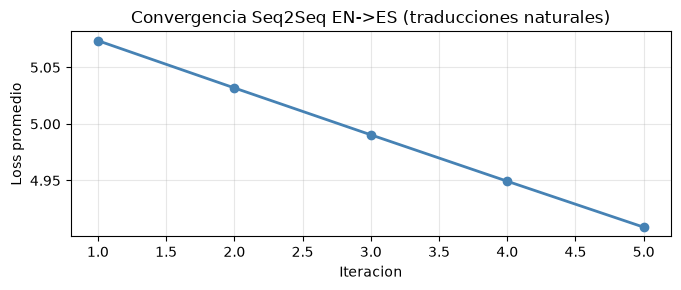

In [183]:
if losses_train:
    plt.figure(figsize=(7,3))
    plt.plot(range(1,6), losses_train, 'o-', color='steelblue', linewidth=2)
    plt.xlabel('Iteracion'); plt.ylabel('Loss promedio')
    plt.title('Convergencia Seq2Seq EN->ES (traducciones naturales)')
    plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('convergencia_seq2seq.png', dpi=110, bbox_inches='tight')
    plt.show()

---
## Bloque 12: Preguntas de analisis

---

### Pregunta 1 (35 pts)

El corpus tiene tres tipos de pares: traducciones mas cortas en espanol (elision del sujeto: *she sings well* -> *canta bien*), mas largas (perifrasis: *the cat sleeps* -> *el gato esta durmiendo*), y del mismo largo.

a) Durante el entrenamiento con teacher forcing, el decoder para el par (*she sings well*, *canta bien*) corre 2 pasos y para (*the cat sleeps*, *el gato esta durmiendo*) corre 4 pasos. Explique como afecta esa diferencia al gradiente que llega a los pesos del encoder en cada caso. Use la formula del recorrido del gradiente $S + T$ pasos.

b) Durante la inferencia greedy, el decoder debe aprender a generar EOS en el momento correcto. Para un par donde el espanol es mas corto que el ingles, ¿que debe haber aprendido el modelo para detener la generacion antes de que el decoder produzca tantos tokens como el encoder proceso? ¿Que informacion del encoder codifica esa senal de parada?

c) Si ordenara el corpus de entrenamiento de menor a mayor largo de la secuencia de salida (curriculum learning), ¿esperaria que el modelo convergiera mas rapido, mas lento, o igual? Justifique en terminos del gradiente y del proceso de aprendizaje.

**Su respuesta a la Pregunta 1:**

a) En ambos casos $T = 3$, así que la diferencia viene solo del lado del decoder. Para *she sings well* los targets son `[canta, bien, EOS]`, es decir $S = 3$;
para *the cat sleeps* son `[el, gato, esta, durmiendo, EOS]`, $S = 5$. (El enunciado menciona 2 y 4 pasos contando solo palabras pero en la implementación 
`dec_target_idx = tgt_tokens[1:]` incluye EOS, por lo que son 3 y 5.)

Con teacher forcing el gradiente que llega a los pesos del encoder debe recorrer $S + T$ celdas LSTM, 6 para *she sings well* y 8 para *the cat sleeps*. Esto tiene repercusiones similares a las discutidas en el laboratorio anterior,
cada celda LSTM causa un decaimiento del gradiente en cada paso. Esto se debe a que en cada uno, este se multiplica por el valor del forget gate.

Consecuentemente, los pares con salidas más largas llevan un gradiente más débil a `Wf_enc`, `Wi_enc`, `Wc_enc`, `Wo_enc`, `E_enc`. Es decir, el encoder aprende "más rápido" de los pares más cortos.

Para esto existe un factor que compensa parcialmente, dentro del código dividimos por $S$. Esto divide la contribución de cada paso, de modo que una secuencia más larga aporta más términos pero cada uno escalado más pequeño. El 
problema no se evita en su totalidad, pero no existe tanto desbalance entre pares.

Además, en la práctica lo que determina si este efecto importa es la varianza de los largos. Si todos los pares tienen un $S$ parecido, la atenuación es uniforme. El problema se puede ver en corpus con largos muy
variados, donde los pares cortos dominarían el aprendizaje.

b) Durante la inferencia greedy el siguiente token se determina por el argmax de los logits, así que `EOS` es simplemente una palabra más del vocabulario. No hay ninguna regla ni contador que detenga el loop, entonces
para parar en el paso correcto, el estado escondido `h` de ese paso debe ser tal que `Wo2 @ h + bo2` asigne el logit más alto a `EOS`.

Ese `h` es el resultado de la recurrencia, depende del estado anterior `(h_{s-1}, c_{s-1})` y del embedding del token que entró en ese paso. Desenrollando hasta el inicio, depende de toda la secuencia de tokens realimentados
 y del estado con el que arrancó el decoder. Es decir, `(context_h, context_c)`.

Si la decisión dependiera únicamente de lo ya generado, el modelo siempre generaría una misma oración y pararía siempre después del mismo número de palabras. Para parar después de 2 en *i drink water* → *bebo agua* pero después de
 4 en *i work every day* → *trabajo todos los dias*, la información que distingue ambos casos tiene que venir de la entrada, y el único canal entre encoder y decoder son esos dos vectores de 32 floats `(context_h, context_c)`.

Por lo tanto el contexto debe codificar implícitamente algo correlacionado con el largo esperado de la salida. No hay ningún término en la loss que lo pida, la señal aparece solo porque el error de predecir `EOS` se propaga hacia atrás
 a través del handoff hasta `Wf_enc`, `E_enc`, etc.

c) Esperaría convergencia más rápida al inicio por lo discutido en (a). Los pares cortos tienen un camino $S + T$ más corto y entregan un gradiente más fuerte al encoder, este efecto se amplifica considerando que los pesos se inicializan
de manera aleatoria y las primeras actualizaciones generan cambios más fuertes. Es decir, las señales más fuertes de las secuencias cortas le dan un ajuste inicial al modelo mientras que las secuencias más largas generan cambios más
leves.

Sin embargo, puede que el modelo vea múltiples ejemplos consecutivos donde `EOS` cae en el mismo paso y se sobreajuste a salidas cortas. Estas son señales que el modelo debe "desaprender" al momento de llegar a los pares largos.

En conclusión, es una técnica que tiene sentido pero los hiperparámetros (y estrategia) de entrenamiento deben ajustarse de manera acorde. Por ejemplo, se podría utilizar curriculum learning en las primeras épocas o realizar pequeños
shuffles conforme las épocas.

---
### Pregunta 2 (35 pts)

a) En el Bloque 10 evalua el porcentaje de oraciones donde la primera palabra generada es correcta. Explique por que esa metrica es mas informativa que la loss de entrenamiento para evaluar la calidad de un sistema de traduccion, y cuales son sus limitaciones.

b) El Bloque 7 muestra que solo una fraccion de las columnas de `E_enc` tienen gradiente no cero en cada actualizacion. Con 78 pares de entrenamiento y 158 palabras en el vocabulario ingles, estime cuantas palabras del vocabulario podrian nunca recibir gradiente durante 5 iteraciones, y que implicacion tiene eso para la representacion de esas palabras.

c) Si quisiera extender este modelo para traducir del espanol al ingles ademas de del ingles al espanol (un solo modelo bidireccional), describa dos enfoques arquitectonicos distintos y justifique cual de los dos preserva mejor la informacion aprendida en este laboratorio.

**Su respuesta a la Pregunta 2:**

a) El porcentaje de oraciones donde la primera palabra generada es correcta fue 0%, para ninguna oración del conjunto de prueba se logró una predicción correcta. Considero que ambas métricas deben tomarse en cuenta, ya que cada
una tiene su caso de uso. En este caso, vimos que la pérdida bajó de 5.037 a 4.903 y aún así no hubo ninguna predicción correcta. Esto se debe a que la pérdida indica la cercanía a la distribución correcta de respuestas, mientras
que la métrica de la primera palabra indica si el argmax fue correcto. El modelo puede mover probabilidades de 0.005 a 0.010 y la pérdida baja sin que el argmax cambie nunca.

Dicho esto, la métrica de la primera palabra funciona más como un smoke test que como una medida de calidad. En este caso logró detectar que el modelo realmente no generaba nada, mientras la pérdida solo indicaba que mejoró desde la primera época. Pero también tiene limitaciones ya que evalúa un único token sin credito parcial ni orden, entonces sería una manera muy poco adecuada de entrenar el modelo. También deja de ser un buen indicador cuando el modelo ya ha alcanzado
ciertas capacidades.

b) En realidad, existen 58 pares de entrenamiento (20 de prueba). Cada secuencia contiene alrededor de 3-4 palabras, entonces la cantidad de ocurrencias de token es $\approx 200$. Además, podemos suponer que las palabras más comunes `the`, `i`, `we`, `he` aparecen en porcentaje alto de nuestras oraciones. Si estimamos que un tercio de todas las palabras son palabras de alta frecuencia y tenemos 8 de estas palabras, tenemos alrededor de 135 ocurrencias para el resto de palabras con poca repetición y aproximadamente 100 palabras únicas (estimando 35 repeticiones). Del vocabulario de 158, vamos a ver alrededor de $158 - 100 = 58$ palabras que nunca reciben gradiente. Alrededor de un tercio del vocabulario.

Además, el hecho que no reciban gradiente no cambia dependiendo de la época. Una palabra ausente en la primera época seguirá ausente en la época 2 tanto como en la época 5000. Entonces, esas columnas se quedan en su inicialización
aleatoria. Si alguna de las palabras aparece durante la inferencia, el embedding "contamina" la predicción al mandar el decoder a un estado aleatorio.

c) 

**Enfoque 1:** dos modelos independientes, uno EN $\rightarrow$ ES y otro ES $\rightarrow$ EN. Cada uno con su encoder, decoder, embeddings y `W_out`, seleccionados según la dirección de la entrada. Cada modelo se entrena solo con su dirección y no comparte ningún parámetro, así que el costo es el doble de memoria y de tiempo de entrenamiento a cambio de independencia total.

**Enfoque 2:** un solo modelo con vocabulario compartido y una etiqueta de dirección al inicio de la fuente (`<2es> i drink water`, `<2en> bebo agua`), de modo que el modelo aprenda a condicionar la generación en ese token. La etiqueta es la primera entrada del encoder, así que queda codificada en el contexto y el decoder la usa para decidir en qué idioma generar.

El primero preserva mejor lo aprendido aquí. El modelo actual es literalmente una de las dos mitades y la implementación de la otra sería casi idéntica. El segundo obliga a fusionar `E_enc` y `E_dec` en una sola tabla y a extender `W_out` sobre ambos idiomas, así que todas las formas cambian y habría que reentrenar desde cero.

---
### Pregunta 3 (30 pts)

a) Si convirtiera este seq2seq en un autoencoder para comprimir oraciones en espanol, describa exactamente los tres cambios de codigo necesarios en el Bloque 9. Sea especifico sobre la funcion de perdida, los tokens de entrada y salida del decoder, y los vocabularios.

b) En el seq2seq, el backward fluye desde la perdida hasta `E_enc` a traves de $S + T$ pasos. En un autoencoder sobre el mismo corpus, ¿ese recorrido seria el mismo, mas corto o mas largo? Justifique considerando que las oraciones de entrada y salida son iguales.

c) El vector de contexto $\mathbf{c}$ de dimension 32 debe comprimir toda la informacion de la entrada. Para las oraciones mas largas del corpus (*nosotros nos reunimos cada semana*, 5 palabras), ¿es suficiente esa dimension? ¿Que pasaria con la calidad de la reconstruccion si redujera la dimension a 2?

**Su respuesta a la Pregunta 3:**

a) El autoencoder toma una oración en español y la reconstruye, así que el encoder y el decoder trabajan sobre el mismo idioma y sobre la misma oración. Los tres cambios en el Bloque 9 son:

**1. Tokenización.** Dentro del loop, `src_indices = tokenize_src(src_sentence)` pasa a ser `src_indices = tokenize_tgt(tgt_sentence)[1:-1]`. Se usa la oración en español y se recortan `SOS` y `EOS`, ya que `tokenize_tgt` los agrega pero el lado del encoder no los necesita.

**2. Tabla de embeddings.** El encoder ahora indexa con índices del vocabulario español, así que `E_enc_tr = torch.randn(d_emb, src_V)` tendría que pasar a `tgt_V`. Pero como encoder y decoder operan sobre el mismo idioma, podemos colapsar ambas tablas en una sola `E_shared = torch.randn(d_emb, tgt_V)` que se pasa tanto a `encoder_forward` como a `decoder_forward`. Esto reduce a la mitad los parámetros de embedding y hace que cada palabra reciba gradiente desde ambos lados.

**3. Acumulación y actualización de esa tabla.** Compartir la tabla obliga a cambiar el paso 7. El Bloque 9 acumula `dE_e` y `dE_d` por separado y aplica dos actualizaciones independientes. Con una sola tabla los gradientes deben sumarse antes de actualizar, `E_shared = E_shared - alpha * (dE_e + dE_d)`. Es el mismo principio con el que las cuatro compuertas suman sus contribuciones en `dL_dconcat`, un solo parámetro que recibe gradiente desde varias rutas.

Vale aclarar que la función de pérdida no cambia. `dec_input_idx = tgt_tokens[:-1]` y `dec_target_idx = tgt_tokens[1:]` conservan la misma forma, el teacher forcing es idéntico, y la pérdida sigue siendo entropía cruzada categórica sobre el vocabulario español. Lo único que cambia es su significado, ahora el target es la reconstrucción de la entrada y no la traducción de otra oración. En código, `compute_loss` no se toca.

*Nota: Separé lo de la tabla de embeddings en 2 porque únicamente identifiqué 2 cambios, en mi opinión realmente debería contar como solo uno pero estoy seguro que la función de pérdida nunca cambia.*

b) Ahora, para la cantidad de pasos tenemos $T = n$ y $S = n + 1$. Entonces, la longitud es de $2n + 1$. Esto depende, generalmente sería más corto ya que las oraciones en español del corpus suelen "botar" palabras y las oraciones en inglés suelen tener más tokens. Es decir, generalmente las salidas del modelo original eran más cortas que las entradas. Si ahora las entradas son iguales a las salidas, entonces el recorrido total es más corto en promedio. Concretamente, para *they play soccer* → *juegan futbol* el seq2seq recorre $3 + 3 = 6$ celdas y el autoencoder sobre *juegan futbol* recorre $2 + 3 = 5$. Cabe aclarar que esto no es una propiedad de la arquitectura sino del corpus, un autoencoder sobre el lado inglés daría un recorrido más largo que el seq2seq.

c) Sí es suficiente, y en realidad son 64 floats y no 32, ya que tanto `context_h` como `context_c` cruzan el handoff. Como referencia, los modelos de embeddings de oraciones que se usan en producción operan en rangos comparables o no mucho mayores: `all-MiniLM-L6-v2` de Sentence-Transformers representa oraciones completas en 384 dimensiones y `text-embedding-3-small` de OpenAI permite truncar a 256 sin pérdida grave (*usé estos de referencia porque son el tipo de modelos de NLP con los que he trabajado, se que estos en realidad están diseñados con otros objetivos y la comparación no es 1:1*). Entonces, 64 floats para una oración de 5 palabras de un vocabulario de 163 no es un cuello de botella severo.

Con dimensión 2 el problema cambia completamente. El contexto se reduce a un punto en un plano donde habría que distinguir 58 oraciones. Además, `d_hid` también dimensiona el estado del decoder, que tendría 2 floats para representar simultáneamente qué reconstruir y en qué posición va. Esperaría que el modelo reconstruyera solo las palabras más frecuentes y colapsara oraciones distintas en la misma salida.


---
## Bloque 13: Nota automatica sobre la seccion de codigo

In [184]:
_PUNTOS = {
    'b2': ('Bloque 2:  Encoder forward',           18),
    'b4': ('Bloque 4:  Perdida CE categorica',       8),
    'b5': ('Bloque 5:  Backward decoder',           14),
    'b6': ('Bloque 6:  Backward encoder',           10),
    'b7': ('Bloque 7:  dE completa vs diccionario',  5),
    'b8': ('Bloque 8:  Actualizacion de pesos',      2),
    'b9': ('Bloque 9:  Convergencia 5 iteraciones',  3),
}
_TOTAL = 60
print('=' * 62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('=' * 62)
_obtenido = 0
for key, (nombre, pts_max) in _PUNTOS.items():
    val = _resultados.get(key, False)
    pts = pts_max if val is True else 0
    _obtenido += pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
if isinstance(_resultados.get('b10'), float):
    print(f'  INFO       | B10 primera palabra test: {_resultados["b10"]:.1f}%')
print('-' * 62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 12 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-' * 62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('=' * 62)

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 2:  Encoder forward             | 18/18 pts
  CORRECTO   | Bloque 4:  Perdida CE categorica       |  8/8 pts
  CORRECTO   | Bloque 5:  Backward decoder            | 14/14 pts
  CORRECTO   | Bloque 6:  Backward encoder            | 10/10 pts
  CORRECTO   | Bloque 7:  dE completa vs diccionario  |  5/5 pts
  CORRECTO   | Bloque 8:  Actualizacion de pesos      |  2/2 pts
  CORRECTO   | Bloque 9:  Convergencia 5 iteraciones  |  3/3 pts
  INFO       | B10 primera palabra test: 0.0%
--------------------------------------------------------------
  Subtotal codigo:   60/60 puntos
  Pendiente manual:
    Bloque 12 preguntas : __/25 pts
    Comentarios codigo  : __/15 pts
--------------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
